In [2]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('placement.csv')

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [7]:
df =df.iloc[:, 1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt

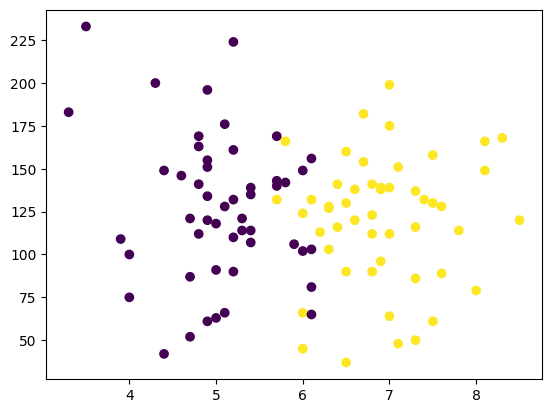

In [10]:

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [14]:

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [15]:

X_train

,cgpa,iq
7,5.0,63.0
19,5.2,132.0
21,7.1,151.0
12,5.4,139.0
39,4.6,146.0
...,...,...
55,7.8,114.0
10,6.0,45.0
64,7.0,64.0
22,4.9,120.0


In [16]:

y_train

7     0
19    0
21    1
12    0
39    0
     ..
55    1
10    1
64    1
22    0
1     0
Name: placement, Length: 90, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler


In [18]:
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)

In [20]:

X_train

array([[-0.908695  , -1.50778957],
       [-0.7259407 ,  0.21500219],
       [ 1.01022517,  0.68939413],
       [-0.5431864 ,  0.38977817],
       [-1.27420361,  0.56455414],
       [ 0.64471657,  0.76429812],
       [ 1.19297948, -0.93352565],
       [ 0.91884802,  1.88785796],
       [ 0.73609372,  0.43971416],
       [ 1.92399669,  0.63945813],
       [ 0.27920796, -0.50906971],
       [ 0.00507651, -1.43288558],
       [-1.45695791,  0.63945813],
       [ 0.18783081, -0.25938974],
       [ 0.82747087, -0.68384568],
       [-0.5431864 ,  0.28990618],
       [ 1.19297948,  0.33984218],
       [-1.09144931,  1.13881806],
       [-1.00007216, -1.55772556],
       [ 0.27920796,  0.09016221],
       [-0.7259407 , -0.83365366],
       [-1.09144931,  0.98901009],
       [ 0.73609372, -0.83365366],
       [-0.63456355, -0.23442175],
       [ 0.46196226,  0.9141061 ],
       [ 0.82747087,  0.38977817],
       [-0.7259407 ,  0.93907409],
       [-2.27935227,  2.73676984],
       [-1.54833506,

In [21]:

X_test = scaler.transform(X_test)

In [22]:

X_test

array([[-0.81731785,  1.31359404],
       [-0.26905495,  0.41474616],
       [ 2.28950529, -0.08461377],
       [ 1.46711093, -0.85862166],
       [ 0.00507651,  0.63945813],
       [-1.09144931, -0.28435774],
       [-2.46210658,  1.48837002],
       [ 0.09645366,  0.21500219],
       [-0.908695  , -0.80868567],
       [ 1.37573378, -1.55772556]])

In [23]:
from sklearn.linear_model import LogisticRegression
     

clf = LogisticRegression()
     

# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [24]:
y_pred = clf.predict(X_test)
     

y_test

15    0
36    0
69    1
42    1
33    0
59    0
17    0
71    1
25    0
44    1
Name: placement, dtype: int64

In [25]:

from sklearn.metrics import accuracy_score
     

accuracy_score(y_test,y_pred)

0.9

In [26]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable


<Axes: >

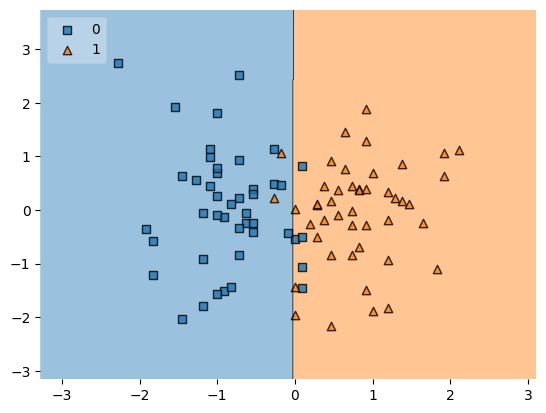

In [27]:
from mlxtend.plotting import plot_decision_regions
     
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [28]:

import pickle
     

pickle.dump(clf,open('model.pkl','wb'))